# Stage 03 - Characteristic CPU Solver Experiments v2 with BG-wall ADAN-86 data

This notebook adapts the Stage 03 characteristic CPU solver to the corrected parser output:

```python
adan_parsed_bg.pkl
```

The important change is that `hv`, `betav`, `c0v`, `Z0v`, and `dt_global` now come from `BG_Modules_v2.cellml` instead of the older constant `h/r = 0.10` fallback.

The solver logic is intentionally kept close to the original Stage 03 notebook so that we can compare boundary-condition variants without changing too many things at once.


## Imports, file paths, and BG parsed data

This cell loads the corrected parser output and, when available, the BG-wall Stage 02 baseline result for comparison.

Expected files:

```text
adan_parsed_bg.pkl
results/baseline_p90_cpu_bg_cfl01_v1.pkl
```

The baseline file is optional. The solver can run without it; only the comparison plot will be skipped.


In [1]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import trapezoid


# Load corrected BG-wall ADAN data

PARSED_FILE = Path("adan_parsed_bg.pkl")

if not PARSED_FILE.exists():
    raise FileNotFoundError(
        f"Missing {PARSED_FILE}. Run the fixed NB01 parser first and save adan_parsed_bg.pkl."
    )

with open(PARSED_FILE, "rb") as f:
    adan = pickle.load(f)

globals().update(adan)

ROOT_IDX = int(np.asarray(root_idx).ravel()[0])
ROOT_VESSEL = order[ROOT_IDX]

parsed_wall_model = adan.get("wall_model", "unknown")
parser_diagnostics = adan.get("diagnostics", adan.get("parser_diagnostics", {}))

print("Loaded BG-wall ADAN parsed data")
print("parsed file:", PARSED_FILE)
print("wall model:", parsed_wall_model)
print("vessels:", len(order))
print("topology rows:", len(topology_df))
print("terminals:", len(terminal_idx))
print("root:", ROOT_IDX, ROOT_VESSEL)
print("c0v range [m/s]:", float(np.min(c0v)), float(np.max(c0v)))
print("unique rounded c0v:", len(np.unique(np.round(c0v, 3))))

if "h_over_r_v" in adan:
    print("h/r range:", float(np.min(h_over_r_v)), float(np.max(h_over_r_v)))



# Optional: load corrected Stage 02 BG baseline for comparison
baseline_cpu = None
baseline_path = None

baseline_candidates = [
    Path("results/baseline_p90_cpu_bg_cfl01_v1.pkl"),
    Path("baseline_p90_cpu_bg_results.pkl"),
]

for candidate in baseline_candidates:
    if candidate.exists():
        baseline_path = candidate
        with open(candidate, "rb") as f:
            baseline_cpu = pickle.load(f)
        break

if baseline_cpu is None:
    print("\nNo baseline file found. External baseline comparison cells will be skipped.")
else:
    print("\nLoaded baseline:", baseline_path)
    print("mode:", baseline_cpu.get("mode", "unknown"))
    print("parsed_file:", baseline_cpu.get("parsed_file", "not recorded"))
    print("dt:", baseline_cpu.get("dt", "not recorded"))
    if "validation" in baseline_cpu:
        print(
            "brachial pressure range:",
            baseline_cpu["validation"].get("brachial_pressure_min_mmHg"),
            baseline_cpu["validation"].get("brachial_pressure_max_mmHg"),
        )


# Long warm-up experiments are kept in the notebook, but disabled by default.
# At this stage we focus on 0.25 s, 1.0 s, and 2.0 s tests.
RUN_OPTIONAL_LONG_RUNS = False


Loaded BG-wall ADAN parsed data
parsed file: adan_parsed_bg.pkl
wall model: bg_modules_v2
vessels: 103
topology rows: 102
terminals: 43
root: 0 ascending_aorta_C0
c0v range [m/s]: 4.542335018453846 18.237569305451796
unique rounded c0v: 68
h/r range: 0.11245008790419994 0.34288287716792476

Loaded baseline: baseline_p90_cpu_bg_results.pkl
mode: baseline_cpu_bg_wall_model
parsed_file: adan_parsed_bg.pkl
dt: 1.867935843904349e-05
brachial pressure range: 88.17804714542386 140.8939009201865


## Common physics helper functions

This section defines the basic physical conversions used throughout the solver.

The solver evolves:

- vessel cross-sectional area `A`,
- volumetric flow `Q`.

Pressure is computed from the same square-root wall law used in the previous notebooks:

```python
P = beta * (sqrt(A) - sqrt(A0))
```

With the BG parser, `beta` is now based on the imported BG wall-thickness law rather than the old constant `h/r = 0.10` approximation.


In [ ]:
def area_to_pressure(A, A0, beta):
    """
    Convert vessel area to pressure using the wall law.

    Args:
        A: Current vessel area.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.

    Returns:
        Pressure value.
    """
    A_safe = np.maximum(A, 1e-14)
    return beta * (np.sqrt(A_safe) - np.sqrt(A0))


def pressure_to_area(P, A0, beta):
    """
    Convert pressure to vessel area using the inverse wall law.

    Args:
        P: Pressure value.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.

    Returns:
        Vessel area.
    """
    sqrt_A = P / beta + np.sqrt(A0)
    sqrt_A = np.maximum(sqrt_A, 1e-14)
    return sqrt_A**2


def local_wave_speed(A, A0, beta, rho=RHO):
    """
    Compute local pulse wave speed from vessel area and stiffness.

    Args:
        A: Current vessel area.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        rho: Blood density.

    Returns:
        Local wave speed.
    """
    A_safe = np.maximum(A, 1e-14)
    return np.sqrt(beta * np.sqrt(A_safe) / (2.0 * rho))


def local_characteristic_impedance(A, A0, beta, rho=RHO):
    """
    Compute local characteristic impedance.

    Args:
        A: Current vessel area.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        rho: Blood density.

    Returns:
        Local characteristic impedance.
    """
    A_safe = np.maximum(A, 1e-14)
    c = local_wave_speed(A_safe, A0, beta, rho)
    return rho * c / A_safe

## Synthetic cardiac inflow waveform

The heart is represented as a prescribed inflow waveform at the aortic root.

No cardiac chambers or valves are modeled in this notebook.  
Instead, the root vessel receives a synthetic one-second cardiac cycle with:

- systolic ejection
- a broad systolic peak
- a small late-systolic shoulder
- a small negative recoil after systole
- calibrated stroke volume

The waveform is scaled so that the integral over one cycle equals the target stroke volume.

This provides a repeatable input signal for comparing different boundary-condition strategies.

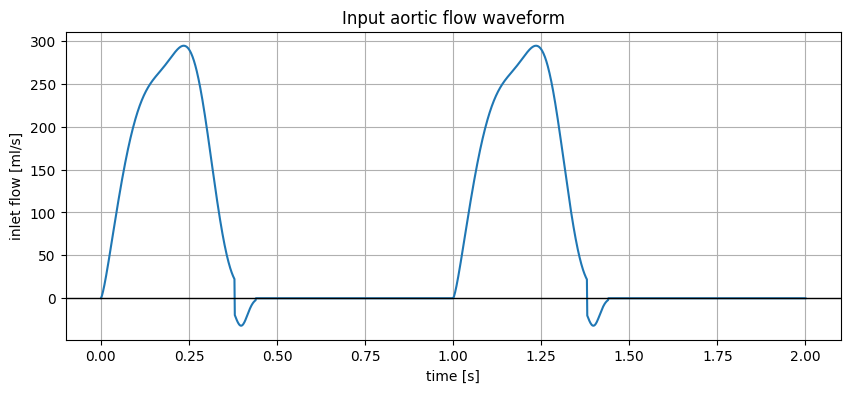

Q peak [ml/s]: 294.398723353155
Q min [ml/s]: -32.0334664240778
SV [ml]: 69.98942574610462


In [ ]:
T_CARDIAC = 1.0
T_SYS = 0.38

STROKE_VOLUME_ML = 70.0
STROKE_VOLUME = STROKE_VOLUME_ML * 1e-6

def inlet_shape_raw(tau):
    """
    Compute the raw dimensionless inlet flow shape.

    Creates a systolic forward-flow pulse with a small negative
    recoil phase after systole.

    Args:
        tau: Time within one cardiac cycle.

    Returns:
        Dimensionless flow shape value.
    """
    if tau < 0.0:
        return 0.0

    if tau < T_SYS:
        x = tau / T_SYS

        a = 1.4
        b = 2.2

        main = (x ** a) * ((1.0 - x) ** b)

        shoulder = 0.06 * np.exp(
            -0.5 * ((tau - 0.27) / 0.055) ** 2
        )

        return main + shoulder

    elif tau < T_SYS + 0.06:
        return -0.012 * np.exp(
            -0.5 * ((tau - (T_SYS + 0.018)) / 0.018) ** 2
        )

    else:
        return 0.0


ts_cal = np.linspace(0, T_CARDIAC, 3000)
shape = np.array([inlet_shape_raw(t) for t in ts_cal])
area_shape = trapezoid(shape, ts_cal)

Q_SCALE = STROKE_VOLUME / area_shape


def inlet_flow(t):
    """
    Compute scaled periodic inlet flow at time t.

    Converts simulation time into cardiac-cycle phase and scales
    the raw inlet shape to match the target stroke volume.

    Args:
        t: Simulation time.

    Returns:
        Inlet flow value.
    """
    tau = t % T_CARDIAC
    return Q_SCALE * inlet_shape_raw(tau)



ts = np.linspace(0, 2.0, 2000)
qs = np.array([inlet_flow(t) for t in ts])

plt.figure(figsize=(10, 4))
plt.plot(ts, qs * 1e6)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("time [s]")
plt.ylabel("inlet flow [ml/s]")
plt.title("Input aortic flow waveform")
plt.grid(True)
plt.show()

print("Q peak [ml/s]:", qs.max() * 1e6)
print("Q min [ml/s]:", qs.min() * 1e6)
print("SV [ml]:", trapezoid(qs[ts < 1.0], ts[ts < 1.0]) * 1e6)

## Initialization, MacCormack update, and stabilizer

The solver starts from a uniform reference pressure of 90 mmHg.

Important BG-wall adaptation:

```python
dt_global = CFL_SOLVER * min(dxv / c0v)
```

Because `c0v` is higher in the BG-wall parser, the safe time step is smaller than in the old parser. This is expected.


In [ ]:
P_REF = 90.0 * MMHG
P_VENOUS = 5.0 * MMHG

ROOT_IDX = int(np.asarray(root_idx).ravel()[0])

CFL_SOLVER = 0.10
dt_global = CFL_SOLVER * np.min(dxv / c0v)

A_ref_v = np.array([
    pressure_to_area(P_REF, A0v[i], betav[i])
    for i in range(len(A0v))
])

print("ROOT_IDX:", ROOT_IDX, order[ROOT_IDX])
print("dt_global:", dt_global)
print("n_steps 0.25s:", int(0.25 / dt_global))
print("n_steps 1s:", int(1.0 / dt_global))
print("n_steps 2s:", int(2.0 / dt_global))
print("max nominal CFL:", float(np.max(c0v * dt_global / dxv)))
print("A_ref/A0 range:", np.min(A_ref_v / A0v), np.max(A_ref_v / A0v))


def initialize_state(A0v, betav, Nv, P_init):
    """
    Initialize vessel area and flow arrays.

    Args:
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Nv: Number of grid points per vessel.
        P_init: Initial pressure.

    Returns:
        (A, Q) initialized vessel area and flow lists.
    """
    A = []
    Q = []

    for i in range(len(A0v)):
        A_init = pressure_to_area(P_init, A0v[i], betav[i])
        A.append(np.full(Nv[i], A_init, dtype=float))
        Q.append(np.zeros(Nv[i], dtype=float))

    return A, Q


def compute_flux(A, Q, A0, beta, rho=RHO):
    """
    Compute conservative fluxes for one vessel.

    Args:
        A: Vessel area array.
        Q: Flow array.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        rho: Blood density.

    Returns:
        (F1, F2) flux arrays.
    """
    A_safe = np.maximum(A, 1e-12)

    P = area_to_pressure(A_safe, A0, beta)

    F1 = Q
    F2 = Q**2 / A_safe + P * A_safe / rho

    return F1, F2


def maccormack_step(A, Q, A0, beta, dx, dt):
    """
    Run one MacCormack step for one vessel.

    Args:
        A: Vessel area array.
        Q: Flow array.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        dx: Spatial step size.
        dt: Time step.

    Returns:
        Updated (A_new, Q_new) arrays.
    """
    N = len(A)

    if N < 3:
        return A, Q

    A_new = A.copy()
    Q_new = Q.copy()

    F1, F2 = compute_flux(A, Q, A0, beta)

    A_pred = A.copy()
    Q_pred = Q.copy()

    A_pred[:-1] = A[:-1] - dt / dx * (F1[1:] - F1[:-1])
    Q_pred[:-1] = Q[:-1] - dt / dx * (F2[1:] - F2[:-1])

    A_pred = np.maximum(A_pred, 1e-12)

    F1p, F2p = compute_flux(A_pred, Q_pred, A0, beta)

    A_new[1:] = 0.5 * (
        A[1:] + A_pred[1:] - dt / dx * (F1p[1:] - F1p[:-1])
    )

    Q_new[1:] = 0.5 * (
        Q[1:] + Q_pred[1:] - dt / dx * (F2p[1:] - F2p[:-1])
    )

    A_new = np.maximum(A_new, 1e-12)

    return A_new, Q_new


def step_all_vessels_uncoupled(A, Q, A0v, betav, dxv, dt):
    """
    Apply one MacCormack step to all vessels independently.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        dxv: Spatial step size per vessel.
        dt: Time step.

    Returns:
        Updated (A_new, Q_new) vessel lists.
    """
    A_new = []
    Q_new = []

    for i in range(len(A)):
        Ai, Qi = maccormack_step(
            A[i],
            Q[i],
            A0v[i],
            betav[i],
            dxv[i],
            dt
        )

        A_new.append(Ai)
        Q_new.append(Qi)

    return A_new, Q_new


def limit_flow_velocity(A, Q, vmax=2.0):
    """
    Limit flow velocity by clipping u = Q / A.

    Args:
        A: Vessel area array.
        Q: Flow array.
        vmax: Maximum allowed velocity magnitude.

    Returns:
        Flow array after velocity limiting.
    """
    A_safe = np.maximum(A, 1e-12)
    u = Q / A_safe
    u_limited = np.clip(u, -vmax, vmax)
    return u_limited * A_safe


def stabilize_all(A, Q, A_ref_v, vmax=2.0):
    """
    Stabilize vessel states by clamping area and velocity.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A_ref_v: Reference area per vessel.
        vmax: Maximum allowed velocity magnitude.

    Returns:
        Stabilized (A, Q) vessel lists.
    """
    for i in range(len(A)):
        A[i] = np.clip(
            A[i],
            0.80 * A_ref_v[i],
            1.50 * A_ref_v[i]
        )

        Q[i] = limit_flow_velocity(
            A[i],
            Q[i],
            vmax=vmax
        )

    return A, Q

ROOT_IDX: 0 ascending_aorta_C0
dt_global: 1.867935843904349e-05
n_steps 0.25s: 13383
n_steps 1s: 53535
n_steps 2s: 107070
max nominal CFL: 0.1
A_ref/A0 range: 1.034322905557006 1.6238796652932406


## Simple flow damping term

This section adds an optional phenomenological damping term to reduce excessive reflected oscillations.

The damping is applied directly to flow `Q`.

It is scaled by vessel radius, so smaller vessels damp more strongly than larger vessels.

This is not a full viscous friction model and not a Womersley correction.  
It is a controlled numerical and physiological damping mechanism used to test whether the brachial waveform becomes smoother and more realistic.

The damping strength is controlled by:

```python
damping_strength

In [ ]:
def apply_flow_damping(Q, Lv, rv, dt, damping_strength=1.0):
    """
    Apply radius-scaled damping to vessel flow arrays.

    Damps flow more strongly in smaller vessels to reduce persistent
    oscillations and improve numerical stability.

    Args:
        Q: List of vessel flow arrays.
        Lv: Vessel lengths.
        rv: Vessel radii.
        dt: Time step.
        damping_strength: Overall damping strength.

    Returns:
        List of damped flow arrays.
    """

    Q_damped = []

    # reference radius to keep numbers reasonable
    r_ref = 0.003  # 3 mm

    for i in range(len(Q)):
        # Smaller radius => stronger damping
        radius_factor = (r_ref / max(rv[i], 1e-6)) ** 2

        # Base damping rate [1/s]
        # Start conservative.
        gamma = damping_strength * 1.5 * radius_factor

        # Avoid insane damping in tiny vessels
        gamma = min(gamma, 25.0)

        decay = np.exp(-gamma * dt)

        Q_damped.append(Q[i] * decay)

    return Q_damped

## Windkessel terminal setup

Each terminal artery is connected to a 3-element Windkessel model.

The terminal model contains:

```text
R1 — proximal resistance
R2 — distal resistance
C  — compliance

In [6]:
TOTAL_R = (100.0 * MMHG - P_VENOUS) / (70e-6)

terminal_A0 = A0v[terminal_idx]
weights = terminal_A0 / terminal_A0.sum()

R_total_i = TOTAL_R / weights

wk_R1 = np.zeros(len(A0v))
wk_R2 = np.zeros(len(A0v))
wk_C = np.zeros(len(A0v))
wk_Pc = np.zeros(len(A0v))

terminal_pos = {
    int(idx): k
    for k, idx in enumerate(terminal_idx)
}

for i in terminal_idx:
    k = terminal_pos[int(i)]

    R_total = R_total_i[k]

    wk_R1[i] = 0.10 * R_total
    wk_R2[i] = 0.90 * R_total

    wk_C[i] = 1.5e-9 * weights[k]
    wk_Pc[i] = P_REF

print("Terminals:", len(terminal_idx))
print("TOTAL_R:", TOTAL_R)
print("R1 range:", wk_R1[wk_R1 > 0].min(), wk_R1.max())
print("R2 range:", wk_R2[wk_R2 > 0].min(), wk_R2.max())
print("C range:", wk_C[wk_C > 0].min(), wk_C.max())

Terminals: 43
TOTAL_R: 180937000.00000003
R1 range: 293747734.9833211 7480205480.287597
R2 range: 2643729614.8498893 67321849322.58836
C range: 3.628316103283905e-12 9.239407412466019e-11


## Root inlet boundary condition

The aortic root uses a Riemann-like inlet boundary condition.

The inlet flow is prescribed from the synthetic cardiac waveform, but inlet pressure is estimated using the first interior point and characteristic impedance.

This avoids over-constraining the system.

Instead of forcing both pressure and flow, the boundary condition:

1. evaluates the desired inflow waveform  
2. reads pressure and flow from the first interior grid point  
3. estimates inlet pressure from a characteristic relation  
4. converts that pressure back into area  
5. sets the inlet flow  

This gives a more stable root boundary than simply assigning pressure and flow independently.

In [ ]:
def apply_root_inlet_riemann(A, Q, root_idx, t, A0v, betav, Z0v):
    """
    Apply a Riemann-like inlet boundary condition at the root vessel.

    Prescribes inlet flow and computes compatible inlet pressure
    and area from the first interior point.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        root_idx: Index of the root vessel.
        t: Current simulation time.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """
    Q_in = inlet_flow(t)

    A_inside = A[root_idx][1]
    Q_inside = Q[root_idx][1]

    P_inside = area_to_pressure(
        A_inside,
        A0v[root_idx],
        betav[root_idx]
    )

    Z = Z0v[root_idx]

    P_in = P_inside + Z * (Q_in - Q_inside)

    P_in = np.clip(
        P_in,
        40.0 * MMHG,
        200.0 * MMHG
    )

    A[root_idx][0] = pressure_to_area(
        P_in,
        A0v[root_idx],
        betav[root_idx]
    )

    Q[root_idx][0] = Q_in

    return A, Q

## Vessel connection boundary-condition variants

This section defines two vessel-connection models.

### 1. Baseline connection model

The baseline method comes from Stage 02.  
It uses fixed characteristic impedance values and a simple pressure-jump relation:

```text
dQ = dP / Z0
```
### 2. Fast characteristic connection model

The fast characteristic method uses the current local area to compute local wave speed and local characteristic impedance.

At each junction, it solves analytically for a shared junction pressure Pj.

For a parent vessel and downstream child vessels, it uses relations of the form:

```
parent outlet: Qj = Qp + (Pp - Pj) / Zp

child inlet:   Qj = Qc + (Pj - Pc) / Zc
```

with mass conservation at the junction.

In [ ]:
def apply_connections_baseline(A, Q, children_map_idx, A0v, betav, Z0v):
    """
    Apply baseline wave-aware coupling at vessel connections.

    Uses shared interface pressure and simple pressure-jump over
    impedance updates for linear connections and bifurcations.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        children_map_idx: Mapping from parent index to child indices.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """

    for parent, children in children_map_idx.items():

        Pp = area_to_pressure(
            A[parent][-1],
            A0v[parent],
            betav[parent]
        )

        Qp = Q[parent][-1]

        # Linear connection
        if len(children) == 1:

            child = children[0]

            Pc = area_to_pressure(
                A[child][0],
                A0v[child],
                betav[child]
            )

            Qc = Q[child][0]

            gp = 1.0 / Z0v[parent]
            gc = 1.0 / Z0v[child]

            # Shared interface pressure
            P_int = (gp * Pp + gc * Pc) / (gp + gc)

            # Child inlet flow response to pressure jump
            Q_child_new = Qc + (P_int - Pc) / Z0v[child]

            # Simple conservation at linear interface
            Q_parent_new = Q_child_new

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[child][0] = pressure_to_area(
                P_int,
                A0v[child],
                betav[child]
            )

            Q[parent][-1] = Q_parent_new
            Q[child][0] = Q_child_new


        # Bifurcation
        elif len(children) == 2:

            c1, c2 = children

            P1 = area_to_pressure(
                A[c1][0],
                A0v[c1],
                betav[c1]
            )

            P2 = area_to_pressure(
                A[c2][0],
                A0v[c2],
                betav[c2]
            )

            Q1_old = Q[c1][0]
            Q2_old = Q[c2][0]

            gp = 1.0 / Z0v[parent]
            g1 = 1.0 / Z0v[c1]
            g2 = 1.0 / Z0v[c2]

            # Shared junction pressure
            P_int = (gp * Pp + g1 * P1 + g2 * P2) / (gp + g1 + g2)

            # Wave-aware child inlet updates
            Q1 = Q1_old + (P_int - P1) / Z0v[c1]
            Q2 = Q2_old + (P_int - P2) / Z0v[c2]

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[c1][0] = pressure_to_area(
                P_int,
                A0v[c1],
                betav[c1]
            )

            A[c2][0] = pressure_to_area(
                P_int,
                A0v[c2],
                betav[c2]
            )

            Q[parent][-1] = Q1 + Q2
            Q[c1][0] = Q1
            Q[c2][0] = Q2

        else:
            raise NotImplementedError(
                f"Parent {parent} {order[parent]} has {len(children)} children"
            )

    return A, Q


def apply_connections_fast_characteristic(A, Q, children_map_idx, A0v, betav):
    """
    Apply fast characteristic coupling at vessel junctions.

    Solves analytically for one shared junction pressure, then updates
    parent outlet and child inlet area and flow values.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        children_map_idx: Mapping from parent index to child indices.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """

    for parent, children in children_map_idx.items():

        # Parent interior near outlet
        A_p = A[parent][-2]
        Q_p = Q[parent][-2]
        P_p = area_to_pressure(A_p, A0v[parent], betav[parent])
        Z_p = local_characteristic_impedance(A_p, A0v[parent], betav[parent])
        g_p = 1.0 / Z_p

        child_data = []

        sum_Qc = 0.0
        sum_Pc_g = 0.0
        sum_g_c = 0.0

        for child in children:
            # Child interior near inlet
            A_c = A[child][1]
            Q_c = Q[child][1]
            P_c = area_to_pressure(A_c, A0v[child], betav[child])
            Z_c = local_characteristic_impedance(A_c, A0v[child], betav[child])
            g_c = 1.0 / Z_c

            child_data.append((child, Q_c, P_c, Z_c, g_c))

            sum_Qc += Q_c
            sum_Pc_g += P_c * g_c
            sum_g_c += g_c

        # From:
        # Qp + (Pp - Pj)/Zp = sum(Qc + (Pj - Pc)/Zc)
        numerator = Q_p - sum_Qc + P_p * g_p + sum_Pc_g
        denominator = g_p + sum_g_c

        Pj = numerator / denominator

        # Numerical safety
        Pj = np.clip(
            Pj,
            30.0 * MMHG,
            200.0 * MMHG
        )

        # Apply parent outlet
        Q_parent_j = Q_p + (P_p - Pj) / Z_p

        A[parent][-1] = pressure_to_area(
            Pj,
            A0v[parent],
            betav[parent]
        )
        Q[parent][-1] = Q_parent_j

        # Apply child inlets
        for child, Q_c, P_c, Z_c, g_c in child_data:

            Q_child_j = Q_c + (Pj - P_c) / Z_c

            A[child][0] = pressure_to_area(
                Pj,
                A0v[child],
                betav[child]
            )
            Q[child][0] = Q_child_j

    return A, Q


def apply_connections_by_mode(A, Q, children_map_idx, A0v, betav, Z0v, mode):
    """
    Apply vessel connection coupling using the selected mode.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        children_map_idx: Mapping from parent index to child indices.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.
        mode: Connection mode name.

    Returns:
        Updated (A, Q) vessel lists.

    Raises:
        ValueError: If mode is unknown.
    """

    if mode == "baseline":
        return apply_connections_baseline(
            A, Q,
            children_map_idx,
            A0v,
            betav,
            Z0v
        )

    elif mode == "fast_characteristic":
        return apply_connections_fast_characteristic(
            A, Q,
            children_map_idx,
            A0v,
            betav
        )

    else:
        raise ValueError(f"Unknown CONNECTION_MODE: {mode}")

## Windkessel boundary-condition variants

This section defines two terminal boundary-condition models.

### 1. Baseline Windkessel

The baseline method uses fixed reference characteristic impedance `Z0v`.

It is the stable terminal boundary condition from Stage 02.

### 2. Fast characteristic Windkessel

The fast characteristic version computes local impedance from the current terminal vessel state.

The terminal relation is:

```text
Qt = (Z · Qinside + Pinside - Pc) / (Z + R1)

In [ ]:
def apply_windkessel_baseline(A, Q, terminal_idx, A0v, betav, Z0v,
                              wk_R1, wk_R2, wk_C, wk_Pc,
                              dt, P_venous=P_VENOUS):
    """
    Apply baseline 3-element Windkessel outlet conditions.

    Uses fixed characteristic impedance to compute terminal flow,
    update capacitor pressure, and impose terminal pressure and flow.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        P_venous: Venous pressure.

    Returns:
        Updated (A, Q, wk_Pc).
    """

    for i in terminal_idx:

        P_inside = area_to_pressure(
            A[i][-2],
            A0v[i],
            betav[i]
        )

        Q_inside = Q[i][-2]
        Z = Z0v[i]

        W_plus = Q_inside + P_inside / Z

        Q_out = (Z * W_plus - wk_Pc[i]) / (Z + wk_R1[i])

        Q_out = np.clip(Q_out, -5e-5, 5e-4)

        dPc_dt = (
            Q_out - (wk_Pc[i] - P_venous) / wk_R2[i]
        ) / wk_C[i]

        wk_Pc[i] += dt * dPc_dt

        wk_Pc[i] = np.clip(
            wk_Pc[i],
            P_venous,
            180.0 * MMHG
        )

        P_terminal = wk_Pc[i] + wk_R1[i] * Q_out

        P_terminal = np.clip(
            P_terminal,
            40.0 * MMHG,
            180.0 * MMHG
        )

        A[i][-1] = pressure_to_area(
            P_terminal,
            A0v[i],
            betav[i]
        )

        Q[i][-1] = Q_out

    return A, Q, wk_Pc


def apply_windkessel_fast_characteristic(A, Q, terminal_idx, A0v, betav,
                                         wk_R1, wk_R2, wk_C, wk_Pc,
                                         dt, P_venous=P_VENOUS):
    """
    Apply fast local-characteristic Windkessel outlet conditions.

    Uses local impedance from the current vessel state to compute
    terminal flow, update capacitor pressure, and impose outlet values.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        P_venous: Venous pressure.

    Returns:
        Updated (A, Q, wk_Pc).
    """

    for i in terminal_idx:

        A_inside = A[i][-2]
        Q_inside = Q[i][-2]

        P_inside = area_to_pressure(
            A_inside,
            A0v[i],
            betav[i]
        )

        Z = local_characteristic_impedance(
            A_inside,
            A0v[i],
            betav[i]
        )

        Pc_old = wk_Pc[i]

        Q_t = (Z * Q_inside + P_inside - Pc_old) / (Z + wk_R1[i])

        Q_t = np.clip(Q_t, -5e-5, 5e-4)

        dPc_dt = (
            Q_t - (wk_Pc[i] - P_venous) / wk_R2[i]
        ) / wk_C[i]

        wk_Pc[i] += dt * dPc_dt

        wk_Pc[i] = np.clip(
            wk_Pc[i],
            P_venous,
            180.0 * MMHG
        )

        P_t = wk_Pc[i] + wk_R1[i] * Q_t

        P_t = np.clip(
            P_t,
            40.0 * MMHG,
            180.0 * MMHG
        )

        A[i][-1] = pressure_to_area(
            P_t,
            A0v[i],
            betav[i]
        )

        Q[i][-1] = Q_t

    return A, Q, wk_Pc


def apply_windkessel_by_mode(A, Q, terminal_idx, A0v, betav, Z0v,
                             wk_R1, wk_R2, wk_C, wk_Pc,
                             dt, mode):
    """
    Apply Windkessel outlet conditions using the selected mode.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        mode: Windkessel mode name.

    Returns:
        Updated (A, Q, wk_Pc).

    Raises:
        ValueError: If mode is unknown.
    """

    if mode == "baseline":
        return apply_windkessel_baseline(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            Z0v,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc,
            dt
        )

    elif mode == "fast_characteristic":
        return apply_windkessel_fast_characteristic(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc,
            dt
        )

    else:
        raise ValueError(f"Unknown WINDKESSEL_MODE: {mode}")

## Reusable solver experiment function

This function runs one complete ADAN-86 CPU solver experiment.

It allows the connection model and Windkessel model to be selected using:

```python
CONNECTION_MODE = "baseline" or "fast_characteristic"
WINDKESSEL_MODE = "baseline" or "fast_characteristic"
```

The function now also records BG-parser metadata in every result dictionary, so later notebooks cannot accidentally mix old constant-wall results with new BG-wall results.


In [ ]:
def run_solver_experiment(
    CONNECTION_MODE="baseline",
    WINDKESSEL_MODE="baseline",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=None,
    damping_strength=0.0,
    verbose=True,
):
    """
    Run one ADAN-86 CPU solver experiment.

    Applies root inlet, vessel junction coupling, Windkessel terminal
    boundaries, stabilization, optional flow damping, and records pressure,
    flow, snapshots, final state, and validation diagnostics.

    Args:
        CONNECTION_MODE: Junction coupling mode.
        WINDKESSEL_MODE: Terminal Windkessel mode.
        T_TEST: Total simulation time.
        CFL_SOLVER: CFL factor used to compute the time step.
        vmax: Maximum allowed velocity.
        snapshot_dt: Time interval between saved snapshots.
        record_start: Start time for recorded outputs.
        record_end: End time for recorded outputs.
        damping_strength: Optional flow damping strength.
        verbose: Whether to print progress and validation info.

    Returns:
        Results dictionary with traces, snapshots, final state,
        metadata, and validation diagnostics.
    """

    # Time step
    dt = CFL_SOLVER * np.min(dxv / c0v)
    n_steps = int(T_TEST / dt)

    if record_end is None:
        record_end = T_TEST

    print_record_window = verbose
    if print_record_window:
        print("record_start:", record_start)
        print("record_end:", record_end)


    # Reference state
    P_REF_LOCAL = 90.0 * MMHG

    A_ref_v_local = np.array([
        pressure_to_area(P_REF_LOCAL, A0v[i], betav[i])
        for i in range(len(A0v))
    ])

    # Initialize A/Q and Windkessel Pc
    A, Q = initialize_state(A0v, betav, Nv, P_REF_LOCAL)

    wk_Pc_run = wk_Pc.copy()
    wk_Pc_run[:] = P_REF_LOCAL

    # Histories
    p_root_hist = []
    q_root_hist = []

    p_brachial_hist = []
    p_brachial_in_hist = []
    p_brachial_mid_hist = []
    p_brachial_out_hist = []

    q_brachial_in_hist = []
    q_brachial_mid_hist = []
    q_brachial_out_hist = []

    t_hist = []

    next_snapshot_t = 0.0
    snapshots = {}

    brachial_idx = vessel_to_idx["brachial_R34"]

    watch_vessel_names = [
        "ascending_aorta_C0",
        "brachial_R34",
        "femoral_R222",
        "posterior_tibial_T4_R236",
        "internal_carotid_R8",
    ]

    watch_vessel_idx = {
        name: vessel_to_idx[name]
        for name in watch_vessel_names
    }

    watch_pressure_hist = {name: [] for name in watch_vessel_names}
    watch_flow_hist = {name: [] for name in watch_vessel_names}

    # Info
    if verbose:
        print("CONNECTION_MODE:", CONNECTION_MODE)
        print("WINDKESSEL_MODE:", WINDKESSEL_MODE)
        print("T_TEST:", T_TEST)
        print("CFL_SOLVER:", CFL_SOLVER)
        print("dt:", dt)
        print("n_steps:", n_steps)
        print("ROOT:", ROOT_IDX, order[ROOT_IDX])
        print("damping_strength:", damping_strength)


    # Main loop
    t_start = time.time()
    bad = False

    for step in range(n_steps):

        t = step * dt
        do_record = (t >= record_start) and (t < record_end)
        t_record = t - record_start

        if verbose and step % 1000 == 0 and step > 0:
            elapsed_now = time.time() - t_start
            progress = step / n_steps
            eta = elapsed_now * (1.0 - progress) / progress

            max_u = max(
                np.max(np.abs(Q[i] / np.maximum(A[i], 1e-12)))
                for i in range(len(A))
            )

            min_area_ratio = min(
                np.min(A[i] / A0v[i])
                for i in range(len(A))
            )

            max_area_ratio = max(
                np.max(A[i] / A0v[i])
                for i in range(len(A))
            )

            print(
                f"[{progress*100:5.1f}%] "
                f"step={step}/{n_steps} | "
                f"t={t:.3f}s | "
                f"elapsed={elapsed_now:.1f}s | "
                f"ETA={eta:.1f}s | "
                f"max|u|={max_u:.2f} m/s | "
                f"min(A/A0)={min_area_ratio:.3f} | "
                f"max(A/A0)={max_area_ratio:.3f}",
                flush=True
            )


        # Root inlet
        A, Q = apply_root_inlet_riemann(
            A, Q,
            root_idx=ROOT_IDX,
            t=t,
            A0v=A0v,
            betav=betav,
            Z0v=Z0v
        )


        # Connections
        A, Q = apply_connections_by_mode(
            A, Q,
            children_map_idx,
            A0v,
            betav,
            Z0v,
            mode=CONNECTION_MODE
        )

        #  Windkessel terminals
        A, Q, wk_Pc_run = apply_windkessel_by_mode(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            Z0v,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc_run,
            dt,
            mode=WINDKESSEL_MODE
        )

        # Stabilize before step
        A, Q = stabilize_all(
            A, Q,
            A_ref_v_local,
            vmax=vmax
        )

        # Solver step
        A, Q = step_all_vessels_uncoupled(
            A, Q,
            A0v,
            betav,
            dxv,
            dt
        )

        # Stabilize after step
        A, Q = stabilize_all(
            A, Q,
            A_ref_v_local,
            vmax=vmax
        )

        # Optional flow damping / friction
        if damping_strength > 0:
            Q = apply_flow_damping(
                Q,
                Lv=Lv,
                rv=rv,
                dt=dt,
                damping_strength=damping_strength
            )

        # Numerical failure check
        for vi in range(len(A)):

            if np.isnan(A[vi]).any() or np.isnan(Q[vi]).any():
                print("NaN in vessel:", vi, order[vi], "at step", step, "t", t)
                bad = True
                break

            if np.isinf(A[vi]).any() or np.isinf(Q[vi]).any():
                print("Inf in vessel:", vi, order[vi], "at step", step, "t", t)
                bad = True
                break

            if np.min(A[vi]) <= 0:
                print("Non-positive A in vessel:", vi, order[vi])
                print("min A:", np.min(A[vi]))
                bad = True
                break

        if bad:
            break

        # Reapply BCs after step
        A, Q = apply_root_inlet_riemann(
            A, Q,
            root_idx=ROOT_IDX,
            t=t,
            A0v=A0v,
            betav=betav,
            Z0v=Z0v
        )

        A, Q = apply_connections_by_mode(
            A, Q,
            children_map_idx,
            A0v,
            betav,
            Z0v,
            mode=CONNECTION_MODE
        )

        A, Q, wk_Pc_run = apply_windkessel_by_mode(
            A, Q,
            terminal_idx,
            A0v,
            betav,
            Z0v,
            wk_R1,
            wk_R2,
            wk_C,
            wk_Pc_run,
            dt,
            mode=WINDKESSEL_MODE
        )

        A, Q = stabilize_all(
            A, Q,
            A_ref_v_local,
            vmax=vmax
        )
        if do_record:
            
            # Record root  
            p_root = area_to_pressure(
                A[ROOT_IDX],
                A0v[ROOT_IDX],
                betav[ROOT_IDX]
            ) / MMHG
    
            p_root_hist.append(p_root[-1])
            q_root_hist.append(Q[ROOT_IDX][-1] * 1e6)
    

            #  Record brachial
            brachial_A = A[brachial_idx]
            brachial_Q = Q[brachial_idx]
    
            mid = len(brachial_A) // 2
    
            p_brachial_in = area_to_pressure(
                brachial_A[0],
                A0v[brachial_idx],
                betav[brachial_idx]
            ) / MMHG
    
            p_brachial_mid = area_to_pressure(
                brachial_A[mid],
                A0v[brachial_idx],
                betav[brachial_idx]
            ) / MMHG
    
            p_brachial_out = area_to_pressure(
                brachial_A[-1],
                A0v[brachial_idx],
                betav[brachial_idx]
            ) / MMHG
    
            p_brachial_hist.append(p_brachial_mid)
    
            p_brachial_in_hist.append(p_brachial_in)
            p_brachial_mid_hist.append(p_brachial_mid)
            p_brachial_out_hist.append(p_brachial_out)
    
            q_brachial_in_hist.append(brachial_Q[0] * 1e6)
            q_brachial_mid_hist.append(brachial_Q[mid] * 1e6)
            q_brachial_out_hist.append(brachial_Q[-1] * 1e6)
    
            t_hist.append(t_record)
    
            #  Watchlist
            for name, idx in watch_vessel_idx.items():
    
                mid_idx = len(A[idx]) // 2
    
                P_mid = area_to_pressure(
                    A[idx][mid_idx],
                    A0v[idx],
                    betav[idx]
                ) / MMHG
    
                Q_mid = Q[idx][mid_idx] * 1e6
    
                watch_pressure_hist[name].append(P_mid)
                watch_flow_hist[name].append(Q_mid)
    

            # Snapshots
            if t_record  >= next_snapshot_t:
    
                vessel_pressures = []
    
                for i in range(len(A)):
    
                    P_i = area_to_pressure(
                        A[i],
                        A0v[i],
                        betav[i]
                    ) / MMHG
    
                    if len(P_i) > 2:
                        p_vis = np.mean(P_i[1:-1])
                    else:
                        p_vis = np.mean(P_i)
    
                    vessel_pressures.append(p_vis)
    
                snapshots[round(next_snapshot_t, 4)] = np.array(vessel_pressures)
                next_snapshot_t += snapshot_dt

    # Convert histories
 

    t_arr = np.array(t_hist)

    p_root_arr = np.array(p_root_hist)
    q_root_arr = np.array(q_root_hist)

    p_brachial_arr = np.array(p_brachial_hist)

    p_brachial_in_arr = np.array(p_brachial_in_hist)
    p_brachial_mid_arr = np.array(p_brachial_mid_hist)
    p_brachial_out_arr = np.array(p_brachial_out_hist)

    q_brachial_in_arr = np.array(q_brachial_in_hist)
    q_brachial_mid_arr = np.array(q_brachial_mid_hist)
    q_brachial_out_arr = np.array(q_brachial_out_hist)

    watch_pressure_arr = {
        name: np.array(vals)
        for name, vals in watch_pressure_hist.items()
    }

    watch_flow_arr = {
        name: np.array(vals)
        for name, vals in watch_flow_hist.items()
    }

    # Results object

    results = {
        "mode": "characteristic_cpu_experiment_bg_wall",
        "description": "Stage 03 characteristic CPU solver using BG-wall ADAN parser output.",
        "parsed_file": str(PARSED_FILE),
        "wall_model": parsed_wall_model,
        "parser_diagnostics": parser_diagnostics,
        "P_REF_mmHg": float(P_REF_LOCAL / MMHG),
        "P_VENOUS_mmHg": float(P_VENOUS / MMHG),
        "root_idx": int(ROOT_IDX),
        "root_vessel": order[ROOT_IDX],
        "n_vessels": int(len(order)),
        "n_terminals": int(len(terminal_idx)),
        "record_start": float(record_start),
        "record_end": float(record_end),
        "snapshot_dt": float(snapshot_dt),
        "CONNECTION_MODE": CONNECTION_MODE,
        "WINDKESSEL_MODE": WINDKESSEL_MODE,
        "T_TEST": T_TEST,
        "dt": dt,
        "CFL_SOLVER": CFL_SOLVER,
        "vmax": vmax,
        "damping_strength": damping_strength,
        "t": t_arr.copy(),

        "p_root": p_root_arr.copy(),
        "q_root": q_root_arr.copy(),

        "p_brachial": p_brachial_arr.copy(),

        "p_brachial_in": p_brachial_in_arr.copy(),
        "p_brachial_mid": p_brachial_mid_arr.copy(),
        "p_brachial_out": p_brachial_out_arr.copy(),

        "q_brachial_in": q_brachial_in_arr.copy(),
        "q_brachial_mid": q_brachial_mid_arr.copy(),
        "q_brachial_out": q_brachial_out_arr.copy(),

        "snapshots": {
            k: v.copy()
            for k, v in snapshots.items()
        },

        "A_final": [a.copy() for a in A],
        "Q_final": [q.copy() for q in Q],
        "wk_Pc_final": wk_Pc_run.copy(),

        "watch_pressure": {
            name: arr.copy()
            for name, arr in watch_pressure_arr.items()
        },

        "watch_flow": {
            name: arr.copy()
            for name, arr in watch_flow_arr.items()
        },

        "watch_vessel_names": watch_vessel_names.copy(),
    }

    # Validation


    if len(t_arr) > 0:
        results["validation"] = {
            "bad": bad,
            "steps_completed": step + 1,
            "n_steps": n_steps,
            "max_CFL_nominal": float(np.max(c0v * dt / dxv)),
            "min_CFL_nominal": float(np.min(c0v * dt / dxv)),
            "c0v_min_m_s": float(np.min(c0v)),
            "c0v_max_m_s": float(np.max(c0v)),
            "unique_rounded_c0v": int(len(np.unique(np.round(c0v, 3)))),

            "any_nan_A": any(np.isnan(x).any() for x in A),
            "any_nan_Q": any(np.isnan(x).any() for x in Q),

            "min_A_over_A0": float(
                min((A[i] / A0v[i]).min() for i in range(len(A)))
            ),
            "max_A_over_A0": float(
                max((A[i] / A0v[i]).max() for i in range(len(A)))
            ),

            "root_pressure_min_mmHg": float(p_root_arr.min()),
            "root_pressure_max_mmHg": float(p_root_arr.max()),

            "root_flow_min_ml_s": float(q_root_arr.min()),
            "root_flow_max_ml_s": float(q_root_arr.max()),

            "brachial_pressure_min_mmHg": float(p_brachial_arr.min()),
            "brachial_pressure_max_mmHg": float(p_brachial_arr.max()),

            "wk_Pc_min_mmHg": float(wk_Pc_run[wk_Pc_run > 0].min() / MMHG),
            "wk_Pc_max_mmHg": float(wk_Pc_run.max() / MMHG),

            "wk_Pc_near_low_clamp": int(
                np.sum(wk_Pc_run[terminal_idx] <= 5.01 * MMHG)
            ),
            "wk_Pc_near_high_clamp": int(
                np.sum(wk_Pc_run[terminal_idx] >= 179.99 * MMHG)
            ),
        }

    if verbose:
        print("\nDONE")
        for k, v in results["validation"].items():
            print(f"{k}: {v}")

    return results

## Boundary-condition experiments

This section compares several solver variants using the corrected BG-wall vessel parameters.

Recommended order for this stage:

1. short baseline reference, 0.25 s;
2. short fast-characteristic connection test, 0.25 s;
3. fast-characteristic connection + baseline Windkessel, 1.0 s;
4. fast-characteristic connection + fast-characteristic Windkessel, 1.0 s;
5. selected 2.0 s characteristic run.

Long warm-up/damping runs are left in the notebook but are disabled by default through:

```python
RUN_OPTIONAL_LONG_RUNS = False
```


### Short baseline reference test

This short test runs the original baseline connection and baseline Windkessel models.

It is used as a quick reference to confirm that the experiment function reproduces the stable Stage 02 behaviour.

In [11]:
test_baseline_025 = run_solver_experiment(
    CONNECTION_MODE="baseline",
    WINDKESSEL_MODE="baseline",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 0.25
CONNECTION_MODE: baseline
WINDKESSEL_MODE: baseline
T_TEST: 0.25
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 13383
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  7.5%] step=1000/13383 | t=0.019s | elapsed=23.2s | ETA=287.4s | max|u|=0.18 m/s | min(A/A0)=1.032 | max(A/A0)=1.625
[ 14.9%] step=2000/13383 | t=0.037s | elapsed=45.5s | ETA=258.7s | max|u|=0.40 m/s | min(A/A0)=1.028 | max(A/A0)=1.639
[ 22.4%] step=3000/13383 | t=0.056s | elapsed=73.6s | ETA=254.8s | max|u|=0.57 m/s | min(A/A0)=1.025 | max(A/A0)=1.661
[ 29.9%] step=4000/13383 | t=0.075s | elapsed=101.2s | ETA=237.3s | max|u|=0.67 m/s | min(A/A0)=1.024 | max(A/A0)=1.685
[ 37.4%] step=5000/13383 | t=0.093s | elapsed=127.6s | ETA=214.0s | max|u|=0.74 m/s | min(A/A0)=1.024 | max(A/A0)=1.720
[ 44.8%] step=6000/13383 | t=0.112s | elapsed=153.0s | ETA=188.2s | max|u|=0.74 m/s | min(A/A0)=1.026 | max(A/A0)=1.760
[ 52.3%] step=7000/13383 | t=0.131s | elapsed=182.7s | ETA=166.6s | max|u|=0.

### Short fast-characteristic connection test

This short test switches only the vessel connection model to `fast_characteristic` while keeping the baseline Windkessel terminal model.

It checks whether the characteristic junction update remains stable with the new BG-wall impedance values.


In [12]:
test_fast_conn_025 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="baseline",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 0.25
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: baseline
T_TEST: 0.25
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 13383
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  7.5%] step=1000/13383 | t=0.019s | elapsed=24.8s | ETA=306.6s | max|u|=0.12 m/s | min(A/A0)=1.032 | max(A/A0)=1.627
[ 14.9%] step=2000/13383 | t=0.037s | elapsed=48.6s | ETA=276.6s | max|u|=0.19 m/s | min(A/A0)=1.031 | max(A/A0)=1.640
[ 22.4%] step=3000/13383 | t=0.056s | elapsed=73.7s | ETA=255.1s | max|u|=0.25 m/s | min(A/A0)=1.031 | max(A/A0)=1.658
[ 29.9%] step=4000/13383 | t=0.075s | elapsed=99.1s | ETA=232.4s | max|u|=0.35 m/s | min(A/A0)=1.031 | max(A/A0)=1.684
[ 37.4%] step=5000/13383 | t=0.093s | elapsed=127.1s | ETA=213.0s | max|u|=0.41 m/s | min(A/A0)=1.032 | max(A/A0)=1.689
[ 44.8%] step=6000/13383 | t=0.112s | elapsed=162.6s | ETA=200.1s | max|u|=0.45 m/s | min(A/A0)=1.033 | max(A/A0)=1.698
[ 52.3%] step=7000/13383 | t=0.131s | elapsed=191.3s | ETA=174.5s |

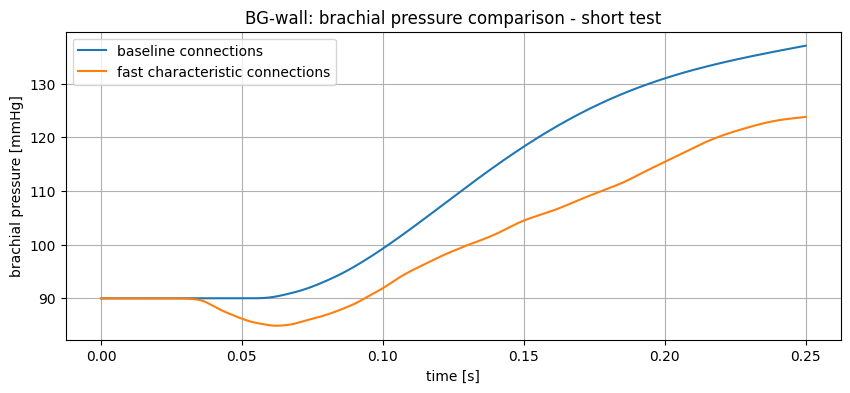

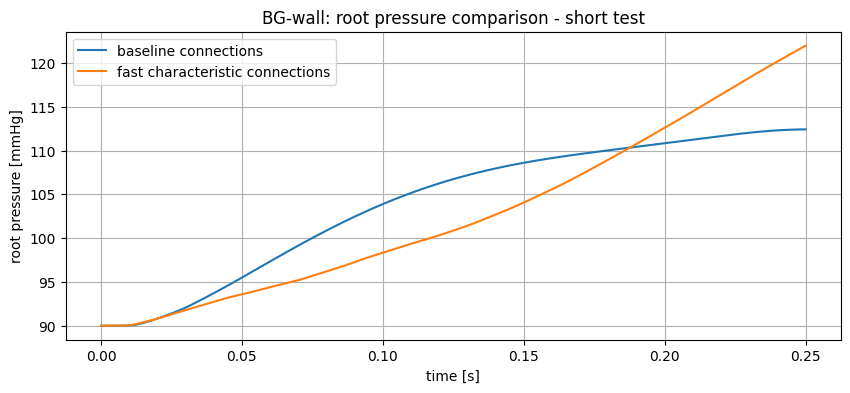

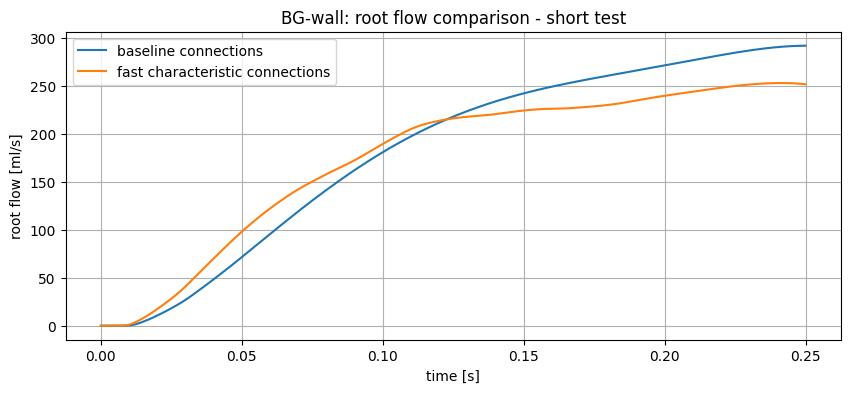

In [13]:
# COMPARE SHORT TEST: BASELINE CONNECTIONS VS FAST CHARACTERISTIC CONNECTIONS
plt.figure(figsize=(10, 4))
plt.plot(
    test_baseline_025["t"],
    test_baseline_025["p_brachial_mid"],
    label="baseline connections"
)
plt.plot(
    test_fast_conn_025["t"],
    test_fast_conn_025["p_brachial_mid"],
    label="fast characteristic connections"
)
plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("BG-wall: brachial pressure comparison - short test")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_baseline_025["t"],
    test_baseline_025["p_root"],
    label="baseline connections"
)
plt.plot(
    test_fast_conn_025["t"],
    test_fast_conn_025["p_root"],
    label="fast characteristic connections"
)
plt.xlabel("time [s]")
plt.ylabel("root pressure [mmHg]")
plt.title("BG-wall: root pressure comparison - short test")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_baseline_025["t"],
    test_baseline_025["q_root"],
    label="baseline connections"
)
plt.plot(
    test_fast_conn_025["t"],
    test_fast_conn_025["q_root"],
    label="fast characteristic connections"
)
plt.xlabel("time [s]")
plt.ylabel("root flow [ml/s]")
plt.title("BG-wall: root flow comparison - short test")
plt.grid(True)
plt.legend()
plt.show()

### One-second fast-connection test

This test runs the fast characteristic connection model for a full cardiac cycle.

The purpose is to check whether the characteristic connection method remains stable beyond a very short trial and whether the brachial waveform begins to differ meaningfully from the baseline solution.

In [14]:
test_fast_conn_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="baseline",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: baseline
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 53535
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  1.9%] step=1000/53535 | t=0.019s | elapsed=27.8s | ETA=1460.7s | max|u|=0.12 m/s | min(A/A0)=1.032 | max(A/A0)=1.627
[  3.7%] step=2000/53535 | t=0.037s | elapsed=47.2s | ETA=1216.1s | max|u|=0.19 m/s | min(A/A0)=1.031 | max(A/A0)=1.640
[  5.6%] step=3000/53535 | t=0.056s | elapsed=67.1s | ETA=1130.5s | max|u|=0.25 m/s | min(A/A0)=1.031 | max(A/A0)=1.658
[  7.5%] step=4000/53535 | t=0.075s | elapsed=86.8s | ETA=1074.5s | max|u|=0.35 m/s | min(A/A0)=1.031 | max(A/A0)=1.684
[  9.3%] step=5000/53535 | t=0.093s | elapsed=108.6s | ETA=1054.4s | max|u|=0.41 m/s | min(A/A0)=1.032 | max(A/A0)=1.689
[ 11.2%] step=6000/53535 | t=0.112s | elapsed=128.1s | ETA=1014.7s | max|u|=0.45 m/s | min(A/A0)=1.033 | max(A/A0)=1.698
[ 13.1%] step=7000/53535 | t=0.131s | elapsed=148.3s | ETA=985.

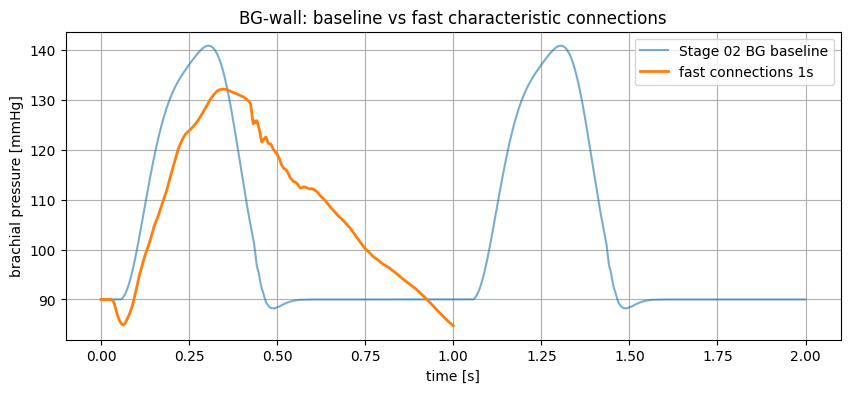

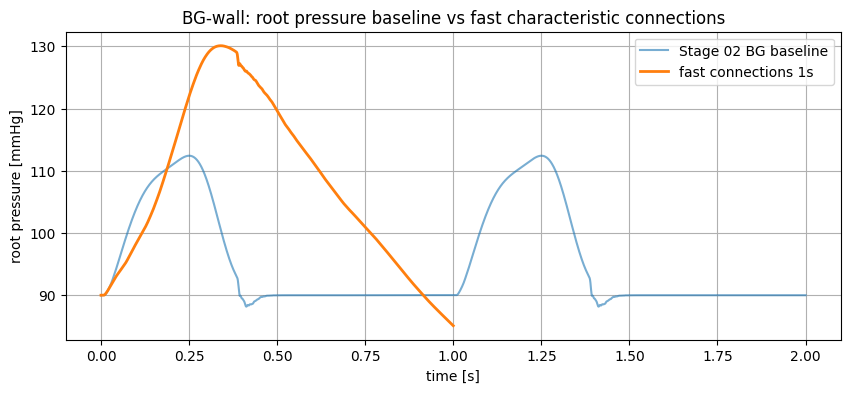

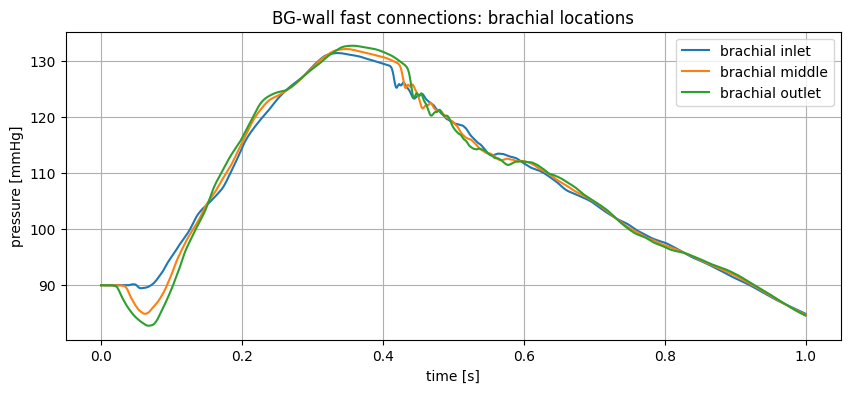

In [15]:
# COMPARE STAGE 02 BG BASELINE VS FAST CONNECTIONS - 1 SECOND TEST

if baseline_cpu is None:
    print("No Stage 02 BG baseline loaded. Skipping external baseline comparison.")
else:
    # COMPARE BASELINE CPU VS FAST CONNECTIONS - 1 SECOND TEST


    plt.figure(figsize=(10, 4))
    plt.plot(
        baseline_cpu["t"],
        baseline_cpu["p_brachial_mid"],
        label="Stage 02 BG baseline",
        alpha=0.6
    )

    plt.plot(
        test_fast_conn_10["t"],
        test_fast_conn_10["p_brachial_mid"],
        label="fast connections 1s",
        linewidth=2
    )

    plt.xlabel("time [s]")
    plt.ylabel("brachial pressure [mmHg]")
    plt.title("BG-wall: baseline vs fast characteristic connections")
    plt.grid(True)
    plt.legend()
    plt.show()


    plt.figure(figsize=(10, 4))
    plt.plot(
        baseline_cpu["t"],
        baseline_cpu["p_root"],
        label="Stage 02 BG baseline",
        alpha=0.6
    )

    plt.plot(
        test_fast_conn_10["t"],
        test_fast_conn_10["p_root"],
        label="fast connections 1s",
        linewidth=2
    )

    plt.xlabel("time [s]")
    plt.ylabel("root pressure [mmHg]")
    plt.title("BG-wall: root pressure baseline vs fast characteristic connections")
    plt.grid(True)
    plt.legend()
    plt.show()


    plt.figure(figsize=(10, 4))
    plt.plot(
        test_fast_conn_10["t"],
        test_fast_conn_10["p_brachial_in"],
        label="brachial inlet"
    )
    plt.plot(
        test_fast_conn_10["t"],
        test_fast_conn_10["p_brachial_mid"],
        label="brachial middle"
    )
    plt.plot(
        test_fast_conn_10["t"],
        test_fast_conn_10["p_brachial_out"],
        label="brachial outlet"
    )

    plt.xlabel("time [s]")
    plt.ylabel("pressure [mmHg]")
    plt.title("BG-wall fast connections: brachial locations")
    plt.grid(True)
    plt.legend()
    plt.show()

### Fast connection plus fast characteristic Windkessel

This experiment enables both characteristic improvements:

```python
CONNECTION_MODE = "fast_characteristic"
WINDKESSEL_MODE = "fast_characteristic"

In [16]:
test_fast_conn_fast_wk_025 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=0.25,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 0.25
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 0.25
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 13383
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  7.5%] step=1000/13383 | t=0.019s | elapsed=21.6s | ETA=267.8s | max|u|=0.12 m/s | min(A/A0)=1.032 | max(A/A0)=1.627
[ 14.9%] step=2000/13383 | t=0.037s | elapsed=44.6s | ETA=253.7s | max|u|=0.19 m/s | min(A/A0)=1.031 | max(A/A0)=1.640
[ 22.4%] step=3000/13383 | t=0.056s | elapsed=71.1s | ETA=246.0s | max|u|=0.25 m/s | min(A/A0)=1.031 | max(A/A0)=1.658
[ 29.9%] step=4000/13383 | t=0.075s | elapsed=102.1s | ETA=239.6s | max|u|=0.35 m/s | min(A/A0)=1.031 | max(A/A0)=1.684
[ 37.4%] step=5000/13383 | t=0.093s | elapsed=131.9s | ETA=221.1s | max|u|=0.41 m/s | min(A/A0)=1.032 | max(A/A0)=1.689
[ 44.8%] step=6000/13383 | t=0.112s | elapsed=153.9s | ETA=189.3s | max|u|=0.45 m/s | min(A/A0)=1.033 | max(A/A0)=1.698
[ 52.3%] step=7000/13383 | t=0.131s | elapsed=176.9s | 

In [17]:
test_fast_conn_fast_wk_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 53535
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  1.9%] step=1000/53535 | t=0.019s | elapsed=22.0s | ETA=1156.5s | max|u|=0.12 m/s | min(A/A0)=1.032 | max(A/A0)=1.627
[  3.7%] step=2000/53535 | t=0.037s | elapsed=40.9s | ETA=1053.8s | max|u|=0.19 m/s | min(A/A0)=1.031 | max(A/A0)=1.640
[  5.6%] step=3000/53535 | t=0.056s | elapsed=59.8s | ETA=1007.4s | max|u|=0.25 m/s | min(A/A0)=1.031 | max(A/A0)=1.658
[  7.5%] step=4000/53535 | t=0.075s | elapsed=80.1s | ETA=991.6s | max|u|=0.35 m/s | min(A/A0)=1.031 | max(A/A0)=1.684
[  9.3%] step=5000/53535 | t=0.093s | elapsed=104.4s | ETA=1013.3s | max|u|=0.41 m/s | min(A/A0)=1.032 | max(A/A0)=1.689
[ 11.2%] step=6000/53535 | t=0.112s | elapsed=130.2s | ETA=1031.5s | max|u|=0.45 m/s | min(A/A0)=1.033 | max(A/A0)=1.698
[ 13.1%] step=7000/53535 | t=0.131s | elapsed=157.7s 

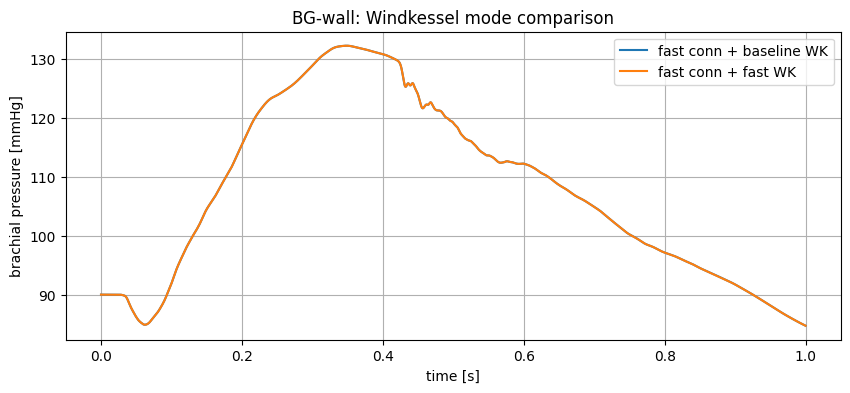

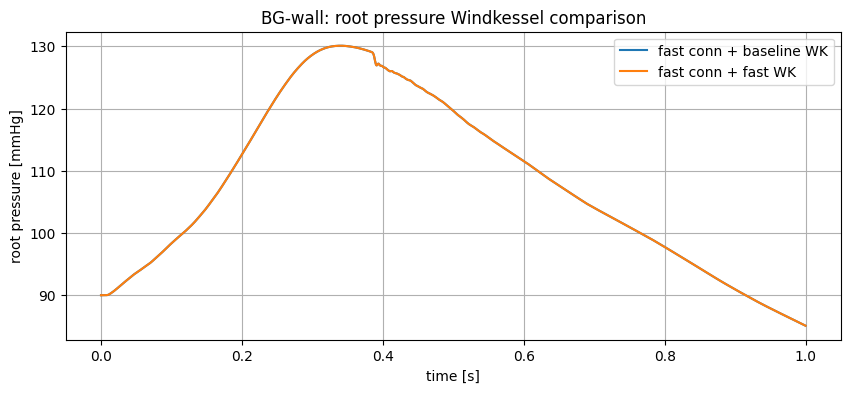

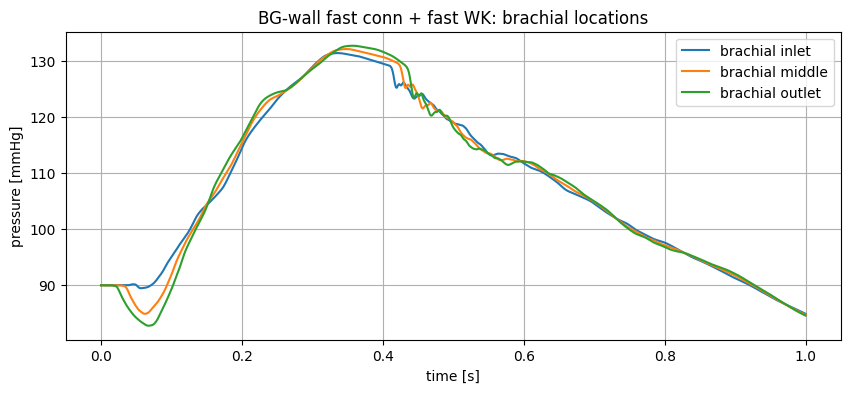

In [ ]:
# COMPARE FAST CONNECTIONS: BASELINE WK VS FAST WK
plt.figure(figsize=(10, 4))
plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_brachial_mid"],
    label="fast conn + baseline WK"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="fast conn + fast WK"
)
plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("BG-wall: Windkessel mode comparison")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_fast_conn_10["t"],
    test_fast_conn_10["p_root"],
    label="fast conn + baseline WK"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_root"],
    label="fast conn + fast WK"
)
plt.xlabel("time [s]")
plt.ylabel("root pressure [mmHg]")
plt.title("BG-wall: root pressure Windkessel comparison")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_in"],
    label="brachial inlet"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="brachial middle"
)
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_out"],
    label="brachial outlet"
)
plt.xlabel("time [s]")
plt.ylabel("pressure [mmHg]")
plt.title("BG-wall fast conn + fast WK: brachial locations")
plt.grid(True)
plt.legend()
plt.show()

### Characteristic fast solver - V1

This is the first longer run using fast characteristic connections and fast characteristic Windkessel terminals.

The goal is to check whether the characteristic solver remains stable over multiple cardiac cycles and whether the pressure waveform is suitable for further tuning.

The first cycle is still affected by the artificial uniform-pressure initialization, so later versions introduce warm-up recording windows.

In [19]:
characteristic_fast_v1 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=2.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    verbose=True,
)

record_start: 0.0
record_end: 2.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 2.0
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 107070
ROOT: 0 ascending_aorta_C0
damping_strength: 0.0
[  0.9%] step=1000/107070 | t=0.019s | elapsed=21.4s | ETA=2273.2s | max|u|=0.12 m/s | min(A/A0)=1.032 | max(A/A0)=1.627
[  1.9%] step=2000/107070 | t=0.037s | elapsed=41.0s | ETA=2155.2s | max|u|=0.19 m/s | min(A/A0)=1.031 | max(A/A0)=1.640
[  2.8%] step=3000/107070 | t=0.056s | elapsed=58.4s | ETA=2027.5s | max|u|=0.25 m/s | min(A/A0)=1.031 | max(A/A0)=1.658
[  3.7%] step=4000/107070 | t=0.075s | elapsed=79.8s | ETA=2055.6s | max|u|=0.35 m/s | min(A/A0)=1.031 | max(A/A0)=1.684
[  4.7%] step=5000/107070 | t=0.093s | elapsed=108.1s | ETA=2207.0s | max|u|=0.41 m/s | min(A/A0)=1.032 | max(A/A0)=1.689
[  5.6%] step=6000/107070 | t=0.112s | elapsed=143.5s | ETA=2417.2s | max|u|=0.45 m/s | min(A/A0)=1.033 | max(A/A0)=1.698
[  6.5%] step=7000/107070 | t=0.131s | elapse

FIRST CYCLE 0-1s
Root pressure: 85.09537529392134 130.10462691615547
Root flow: -21.535022623446515 252.9185900654572
Brachial pressure: 84.73044634478813 132.19658669673515

SECOND CYCLE 1-2s
Root pressure: 82.29273844785105 125.51448109661133
Root flow: -24.24495012917367 251.6465406568465
Brachial pressure: 81.72298566351589 128.57255075584592


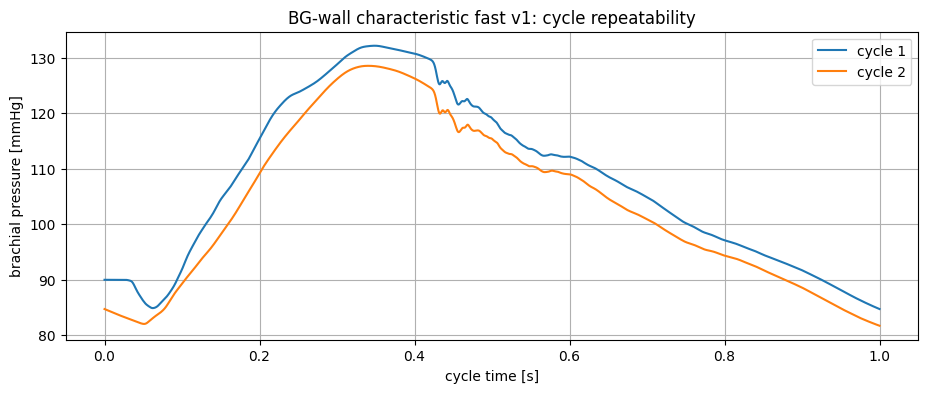

In [20]:
# CYCLE DIAGNOSTICS FOR CHARACTERISTIC FAST V1

res = characteristic_fast_v1

t = res["t"]
p_root = res["p_root"]
q_root = res["q_root"]
p_brachial = res["p_brachial"]

mask1 = (t >= 0.0) & (t < 1.0)
mask2 = (t >= 1.0) & (t < 2.0)

print("FIRST CYCLE 0-1s")
print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

print("\nSECOND CYCLE 1-2s")
print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

plt.figure(figsize=(11, 4))
plt.plot(t[mask1], p_brachial[mask1], label="cycle 1")
plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="cycle 2")
plt.xlabel("cycle time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("BG-wall characteristic fast v1: cycle repeatability")
plt.grid(True)
plt.legend()
plt.show()

In [21]:
# SAVE CHARACTERISTIC FAST V1
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

characteristic_fast_v1["description"] = (
    "BG-wall ADAN-86 CPU solver with fast linearized characteristic connections "
    "and fast local-characteristic Windkessel terminals. "
    "Stable 2-second run, CFL=0.10."
)

characteristic_fast_v1["validation_note"] = (
    "Stable run without NaN and without Windkessel clamp hits. "
    "Cycle 2 shows slightly lower brachial diastolic pressure than cycle 1, "
    "so for final production keep this as the first BG-wall characteristic reference before any later production tuning."
)


# Keep result provenance explicit.
characteristic_fast_v1["parsed_file"] = str(PARSED_FILE)
characteristic_fast_v1["wall_model"] = parsed_wall_model
characteristic_fast_v1["parser_diagnostics"] = parser_diagnostics
characteristic_fast_v1["root_vessel"] = ROOT_VESSEL

output_path = RESULTS_DIR / "characteristic_bg_fast_conn_fast_wk_cfl01_v1.pkl"

with open(output_path, "wb") as f:
    pickle.dump(characteristic_fast_v1, f)

print("Saved:", output_path.resolve())
print("File size MB:", output_path.stat().st_size / 1024 / 1024)

Saved: D:\code\adan_project\results\characteristic_bg_fast_conn_fast_wk_cfl01_v1.pkl
File size MB: 16.54535675048828


### Optional: characteristic fast solver - V2 with warm-up

This version runs for three seconds and records only after the first second.

For the current BG-wall adaptation stage this cell is disabled by default. Set:

```python
RUN_OPTIONAL_LONG_RUNS = True
```

only when you deliberately want to spend time on longer warm-up tests.


In [22]:
# Optional long experiment: V2 3-second warm-up characteristic run

if RUN_OPTIONAL_LONG_RUNS:
    characteristic_fast_warmup_v2 = run_solver_experiment(
        CONNECTION_MODE="fast_characteristic",
        WINDKESSEL_MODE="fast_characteristic",
        T_TEST=3.0,
        CFL_SOLVER=0.10,
        vmax=2.0,
        snapshot_dt=0.01,
        record_start=1.0,
        record_end=3.0,
        verbose=True,
    )
else:
    characteristic_fast_warmup_v2 = None
    print("Skipped V2 3-second warm-up characteristic run. Set RUN_OPTIONAL_LONG_RUNS = True to run it.")


Skipped V2 3-second warm-up characteristic run. Set RUN_OPTIONAL_LONG_RUNS = True to run it.


In [23]:
# Optional cell for: V2 diagnostics

if characteristic_fast_warmup_v2 is not None:
    res = characteristic_fast_warmup_v2

    t = res["t"]
    p_root = res["p_root"]
    q_root = res["q_root"]
    p_brachial = res["p_brachial"]

    mask1 = (t >= 0.0) & (t < 1.0)
    mask2 = (t >= 1.0) & (t < 2.0)

    print("RECORDED CYCLE 1")
    print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
    print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
    print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

    print("\nRECORDED CYCLE 2")
    print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
    print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
    print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

    plt.figure(figsize=(11, 4))
    plt.plot(t[mask1], p_brachial[mask1], label="recorded cycle 1")
    plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="recorded cycle 2")
    plt.xlabel("cycle time [s]")
    plt.ylabel("brachial pressure [mmHg]")
    plt.title("BG-wall characteristic warm-up v2: cycle repeatability")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Skipped V2 diagnostics because characteristic_fast_warmup_v2 was not run.")


Skipped V2 diagnostics because characteristic_fast_warmup_v2 was not run.


In [24]:
# Optional cell for: V2 save

if characteristic_fast_warmup_v2 is not None:
    # SAVE CHARACTERISTIC FAST WARMUP V2

    RESULTS_DIR = Path("results")
    RESULTS_DIR.mkdir(exist_ok=True)

    characteristic_fast_warmup_v2["description"] = (
        "BG-wall ADAN-86 CPU solver with fast linearized characteristic connections "
        "and fast local-characteristic Windkessel terminals. "
        "3-second simulation with first 1 second used as warm-up; "
        "recorded output window is 1–3 s."
    )

    characteristic_fast_warmup_v2["record_start"] = 1.0
    characteristic_fast_warmup_v2["record_end"] = 3.0


    # Keep result provenance explicit.
    characteristic_fast_warmup_v2["parsed_file"] = str(PARSED_FILE)
    characteristic_fast_warmup_v2["wall_model"] = parsed_wall_model
    characteristic_fast_warmup_v2["parser_diagnostics"] = parser_diagnostics
    characteristic_fast_warmup_v2["root_vessel"] = ROOT_VESSEL

    output_path = RESULTS_DIR / "characteristic_bg_fast_warmup_record_last2s_cfl01_v2.pkl"

    with open(output_path, "wb") as f:
        pickle.dump(characteristic_fast_warmup_v2, f)

    print("Saved:", output_path.resolve())
    print("File size MB:", output_path.stat().st_size / 1024 / 1024)
else:
    print("Skipped V2 save because characteristic_fast_warmup_v2 was not run.")


Skipped V2 save because characteristic_fast_warmup_v2 was not run.


### Optional: characteristic fast solver — V3 with longer warm-up

This version runs for four seconds and records only after two seconds.

It is disabled by default in this adapted notebook because we are first checking whether the BG-wall characteristic solver works, not doing long production runs yet.


In [25]:
# Optional long experiment: V3 4-second warm-up characteristic run

if RUN_OPTIONAL_LONG_RUNS:
    characteristic_fast_warmup_v3 = run_solver_experiment(
        CONNECTION_MODE="fast_characteristic",
        WINDKESSEL_MODE="fast_characteristic",
        T_TEST=4.0,
        CFL_SOLVER=0.10,
        vmax=2.0,
        snapshot_dt=0.01,
        record_start=2.0,
        record_end=4.0,
        verbose=True,
    )
else:
    characteristic_fast_warmup_v3 = None
    print("Skipped V3 4-second warm-up characteristic run. Set RUN_OPTIONAL_LONG_RUNS = True to run it.")


Skipped V3 4-second warm-up characteristic run. Set RUN_OPTIONAL_LONG_RUNS = True to run it.


In [26]:
# Optional cell for: V3 diagnostics

if characteristic_fast_warmup_v3 is not None:
    # CYCLE DIAGNOSTICS FOR CHARACTERISTIC FAST WARMUP V3

    res = characteristic_fast_warmup_v3

    t = res["t"]
    p_root = res["p_root"]
    q_root = res["q_root"]
    p_brachial = res["p_brachial"]

    mask1 = (t >= 0.0) & (t < 1.0)
    mask2 = (t >= 1.0) & (t < 2.0)

    print("RECORDED CYCLE 1")
    print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
    print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
    print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

    print("\nRECORDED CYCLE 2")
    print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
    print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
    print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

    plt.figure(figsize=(11, 4))
    plt.plot(t[mask1], p_brachial[mask1], label="recorded cycle 1")
    plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="recorded cycle 2")
    plt.xlabel("cycle time [s]")
    plt.ylabel("brachial pressure [mmHg]")
    plt.title("BG-wall characteristic warm-up v3: cycle repeatability")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Skipped V3 diagnostics because characteristic_fast_warmup_v3 was not run.")


Skipped V3 diagnostics because characteristic_fast_warmup_v3 was not run.


In [27]:
# Optional cell for: V3 save

if characteristic_fast_warmup_v3 is not None:
    # SAVE CHARACTERISTIC FAST WARMUP V3
    RESULTS_DIR = Path("results")
    RESULTS_DIR.mkdir(exist_ok=True)

    characteristic_fast_warmup_v3["description"] = (
        "BG-wall ADAN-86 CPU solver with fast linearized characteristic connections "
        "and fast local-characteristic Windkessel terminals. "
        "4-second simulation with first 2 seconds used as warm-up; "
        "recorded output window is 2–4 s."
    )

    characteristic_fast_warmup_v3["record_start"] = 2.0
    characteristic_fast_warmup_v3["record_end"] = 4.0
    characteristic_fast_warmup_v3["version"] = "v3_warmup_last2s"
    characteristic_fast_warmup_v3["recommended_for_animation"] = True


    # Keep result provenance explicit.
    characteristic_fast_warmup_v3["parsed_file"] = str(PARSED_FILE)
    characteristic_fast_warmup_v3["wall_model"] = parsed_wall_model
    characteristic_fast_warmup_v3["parser_diagnostics"] = parser_diagnostics
    characteristic_fast_warmup_v3["root_vessel"] = ROOT_VESSEL

    output_path = RESULTS_DIR / "characteristic_bg_fast_warmup_record_last2s_cfl01_v3.pkl"

    with open(output_path, "wb") as f:
        pickle.dump(characteristic_fast_warmup_v3, f)

    print("Saved:", output_path.resolve())
    print("File size MB:", output_path.stat().st_size / 1024 / 1024)
else:
    print("Skipped V3 save because characteristic_fast_warmup_v3 was not run.")


Skipped V3 save because characteristic_fast_warmup_v3 was not run.


### Damping experiment

The characteristic solver can produce persistent reflected oscillations.

This section tests whether adding simple flow damping improves the brachial waveform.

The damping term is not intended as a final physiological friction model.  
It is a controlled experiment to see whether modest energy loss produces a cleaner peripheral pressure trace.

In [28]:
test_fast_damp_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=1.0,
    damping_strength=0.5,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 53535
ROOT: 0 ascending_aorta_C0
damping_strength: 0.5
[  1.9%] step=1000/53535 | t=0.019s | elapsed=18.5s | ETA=970.1s | max|u|=0.12 m/s | min(A/A0)=1.031 | max(A/A0)=1.627
[  3.7%] step=2000/53535 | t=0.037s | elapsed=35.8s | ETA=921.8s | max|u|=0.19 m/s | min(A/A0)=1.030 | max(A/A0)=1.640
[  5.6%] step=3000/53535 | t=0.056s | elapsed=53.6s | ETA=903.1s | max|u|=0.25 m/s | min(A/A0)=1.030 | max(A/A0)=1.658
[  7.5%] step=4000/53535 | t=0.075s | elapsed=71.0s | ETA=879.0s | max|u|=0.34 m/s | min(A/A0)=1.030 | max(A/A0)=1.684
[  9.3%] step=5000/53535 | t=0.093s | elapsed=89.0s | ETA=863.5s | max|u|=0.41 m/s | min(A/A0)=1.030 | max(A/A0)=1.690
[ 11.2%] step=6000/53535 | t=0.112s | elapsed=107.1s | ETA=848.3s | max|u|=0.45 m/s | min(A/A0)=1.032 | max(A/A0)=1.699
[ 13.1%] step=7000/53535 | t=0.131s | elapsed=124.7s | ETA=

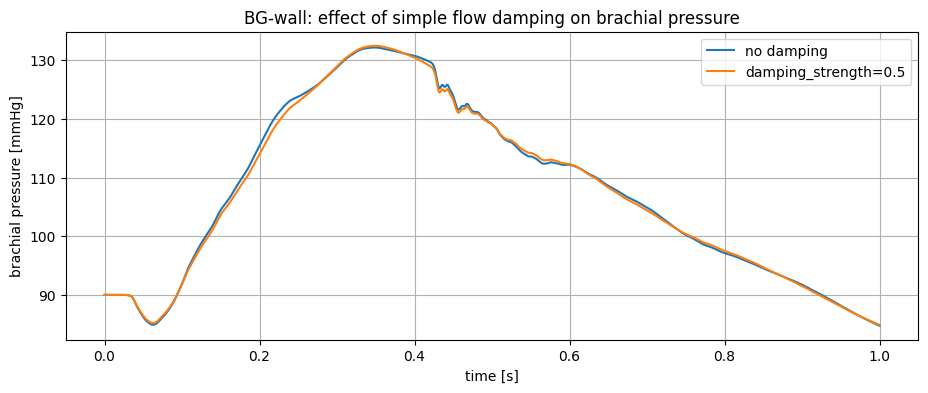

In [29]:
plt.figure(figsize=(11, 4))
plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="no damping"
)
plt.plot(
    test_fast_damp_10["t"],
    test_fast_damp_10["p_brachial_mid"],
    label="damping_strength=0.5"
)
plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("BG-wall: effect of simple flow damping on brachial pressure")
plt.grid(True)
plt.legend()
plt.show()

### Damping strength sweep

Here we compare different values of `damping_strength`.

The goal is to find a damping level that reduces unrealistic oscillations without flattening the physiological pressure waveform too much.

A useful damping value should:

- preserve the systolic upstroke
- keep a visible peripheral pressure pulse
- reduce excessive high-frequency ringing
- avoid collapsing pulse pressure

In [30]:
test_fast_damp_025_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=1.0,
    damping_strength=0.25,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 53535
ROOT: 0 ascending_aorta_C0
damping_strength: 0.25
[  1.9%] step=1000/53535 | t=0.019s | elapsed=50.4s | ETA=2645.8s | max|u|=0.12 m/s | min(A/A0)=1.032 | max(A/A0)=1.627
[  3.7%] step=2000/53535 | t=0.037s | elapsed=79.8s | ETA=2055.8s | max|u|=0.19 m/s | min(A/A0)=1.031 | max(A/A0)=1.640
[  5.6%] step=3000/53535 | t=0.056s | elapsed=105.5s | ETA=1777.6s | max|u|=0.25 m/s | min(A/A0)=1.030 | max(A/A0)=1.658
[  7.5%] step=4000/53535 | t=0.075s | elapsed=139.8s | ETA=1731.7s | max|u|=0.34 m/s | min(A/A0)=1.030 | max(A/A0)=1.684
[  9.3%] step=5000/53535 | t=0.093s | elapsed=166.3s | ETA=1613.8s | max|u|=0.41 m/s | min(A/A0)=1.031 | max(A/A0)=1.690
[ 11.2%] step=6000/53535 | t=0.112s | elapsed=190.6s | ETA=1509.8s | max|u|=0.45 m/s | min(A/A0)=1.032 | max(A/A0)=1.698
[ 13.1%] step=7000/53535 | t=0.131s | elapsed=216

In [31]:
test_fast_damp_100_10 = run_solver_experiment(
    CONNECTION_MODE="fast_characteristic",
    WINDKESSEL_MODE="fast_characteristic",
    T_TEST=1.0,
    CFL_SOLVER=0.10,
    vmax=2.0,
    snapshot_dt=0.01,
    record_start=0.0,
    record_end=1.0,
    damping_strength=1.0,
    verbose=True,
)

record_start: 0.0
record_end: 1.0
CONNECTION_MODE: fast_characteristic
WINDKESSEL_MODE: fast_characteristic
T_TEST: 1.0
CFL_SOLVER: 0.1
dt: 1.867935843904349e-05
n_steps: 53535
ROOT: 0 ascending_aorta_C0
damping_strength: 1.0
[  1.9%] step=1000/53535 | t=0.019s | elapsed=20.1s | ETA=1056.9s | max|u|=0.12 m/s | min(A/A0)=1.031 | max(A/A0)=1.627
[  3.7%] step=2000/53535 | t=0.037s | elapsed=39.9s | ETA=1028.8s | max|u|=0.19 m/s | min(A/A0)=1.030 | max(A/A0)=1.640
[  5.6%] step=3000/53535 | t=0.056s | elapsed=58.5s | ETA=984.7s | max|u|=0.24 m/s | min(A/A0)=1.029 | max(A/A0)=1.657
[  7.5%] step=4000/53535 | t=0.075s | elapsed=78.0s | ETA=965.4s | max|u|=0.34 m/s | min(A/A0)=1.029 | max(A/A0)=1.684
[  9.3%] step=5000/53535 | t=0.093s | elapsed=95.8s | ETA=930.3s | max|u|=0.40 m/s | min(A/A0)=1.029 | max(A/A0)=1.690
[ 11.2%] step=6000/53535 | t=0.112s | elapsed=114.3s | ETA=905.5s | max|u|=0.45 m/s | min(A/A0)=1.030 | max(A/A0)=1.700
[ 13.1%] step=7000/53535 | t=0.131s | elapsed=134.7s | ET

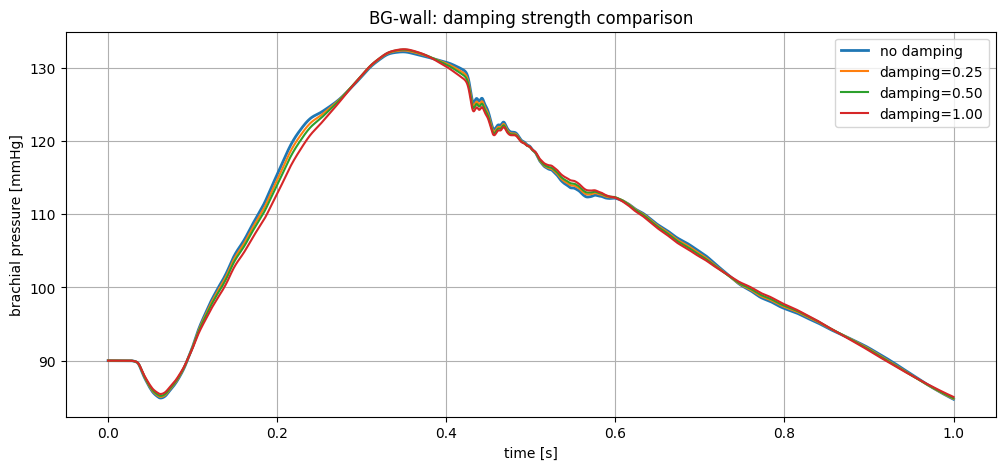

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_fast_conn_fast_wk_10["t"],
    test_fast_conn_fast_wk_10["p_brachial_mid"],
    label="no damping",
    linewidth=2
)

plt.plot(
    test_fast_damp_025_10["t"],
    test_fast_damp_025_10["p_brachial_mid"],
    label="damping=0.25"
)

plt.plot(
    test_fast_damp_10["t"],
    test_fast_damp_10["p_brachial_mid"],
    label="damping=0.50"
)

plt.plot(
    test_fast_damp_100_10["t"],
    test_fast_damp_100_10["p_brachial_mid"],
    label="damping=1.00"
)

plt.xlabel("time [s]")
plt.ylabel("brachial pressure [mmHg]")
plt.title("BG-wall: damping strength comparison")
plt.grid(True)
plt.legend()
plt.show()

### Optional: characteristic fast damped solver - V4

This is the damped long-run variant from the original notebook.

It is kept for later comparison, but disabled by default. For now, use the 0.25 s, 1.0 s, and 2.0 s tests to evaluate whether the characteristic solver behaves sensibly with `adan_parsed_bg.pkl`.


In [33]:
# Optional long experiment: V4 4-second damped characteristic run

if RUN_OPTIONAL_LONG_RUNS:
    characteristic_fast_damped_v4 = run_solver_experiment(
        CONNECTION_MODE="fast_characteristic",
        WINDKESSEL_MODE="fast_characteristic",
        T_TEST=4.0,
        CFL_SOLVER=0.10,
        vmax=2.0,
        snapshot_dt=0.01,
        record_start=2.0,
        record_end=4.0,
        damping_strength=0.5,
        verbose=True,
    )
else:
    characteristic_fast_damped_v4 = None
    print("Skipped V4 4-second damped characteristic run. Set RUN_OPTIONAL_LONG_RUNS = True to run it.")


Skipped V4 4-second damped characteristic run. Set RUN_OPTIONAL_LONG_RUNS = True to run it.


# Final cycle diagnostics

This section evaluates the final selected characteristic solver variant.

The diagnostics inspect:

- root pressure range
- root flow range
- brachial pressure range
- first recorded cycle
- second recorded cycle
- whether the waveform remains stable after warm-up

The key question is whether the brachial waveform is plausible enough to use as the live waveform panel in the final animation.

In [34]:
# Optional cell for: V4 diagnostics

if characteristic_fast_damped_v4 is not None:
    # CYCLE DIAGNOSTICS FOR CHARACTERISTIC FAST DAMPED V4

    res = characteristic_fast_damped_v4

    t = res["t"]
    p_root = res["p_root"]
    q_root = res["q_root"]
    p_brachial = res["p_brachial"]

    mask1 = (t >= 0.0) & (t < 1.0)
    mask2 = (t >= 1.0) & (t < 2.0)

    print("RECORDED CYCLE 1")
    print("Root pressure:", p_root[mask1].min(), p_root[mask1].max())
    print("Root flow:", q_root[mask1].min(), q_root[mask1].max())
    print("Brachial pressure:", p_brachial[mask1].min(), p_brachial[mask1].max())

    print("\nRECORDED CYCLE 2")
    print("Root pressure:", p_root[mask2].min(), p_root[mask2].max())
    print("Root flow:", q_root[mask2].min(), q_root[mask2].max())
    print("Brachial pressure:", p_brachial[mask2].min(), p_brachial[mask2].max())

    plt.figure(figsize=(11, 4))
    plt.plot(t[mask1], p_brachial[mask1], label="recorded cycle 1")
    plt.plot(t[mask2] - 1.0, p_brachial[mask2], label="recorded cycle 2")
    plt.xlabel("cycle time [s]")
    plt.ylabel("brachial pressure [mmHg]")
    plt.title("BG-wall characteristic damped v4: cycle repeatability")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Skipped V4 diagnostics because characteristic_fast_damped_v4 was not run.")


Skipped V4 diagnostics because characteristic_fast_damped_v4 was not run.


## Compare undamped and damped characteristic solver

This comparison shows the effect of damping on the right brachial pressure waveform.

The undamped characteristic solver can preserve too much reflected wave energy, which may create non-physiological oscillations.

The damped version should ideally keep the main pulse shape while reducing excessive ringing.

In [35]:
# Optional comparison: V3 no damping vs V4 damped

if characteristic_fast_warmup_v3 is not None and characteristic_fast_damped_v4 is not None:
    # COMPARE V3 NO DAMPING VS V4 DAMPED
    plt.figure(figsize=(12, 5))

    plt.plot(
        characteristic_fast_warmup_v3["t"],
        characteristic_fast_warmup_v3["p_brachial_mid"],
        label="v3 no damping",
        linewidth=2
    )

    plt.plot(
        characteristic_fast_damped_v4["t"],
        characteristic_fast_damped_v4["p_brachial_mid"],
        label="v4 damping=0.5",
        linewidth=2
    )

    plt.xlabel("recorded time [s]")
    plt.ylabel("brachial pressure [mmHg]")
    plt.title("BG-wall: v3 vs v4")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Skipped V3 vs V4 comparison because optional long runs were not executed.")


Skipped V3 vs V4 comparison because optional long runs were not executed.


## Optional: save selected characteristic solver result

This block saves the final damped V4 solver output only if the optional long run was executed.

At this adaptation stage, the main BG-wall result to inspect first is the 2-second V1 output:

```text
results/characteristic_bg_fast_conn_fast_wk_cfl01_v1.pkl
```


In [36]:
# Optional cell for: V4 save

if characteristic_fast_damped_v4 is not None:
    # SAVE CHARACTERISTIC FAST DAMPED V4
    RESULTS_DIR = Path("results")
    RESULTS_DIR.mkdir(exist_ok=True)

    characteristic_fast_damped_v4["description"] = (
        "BG-wall ADAN-86 CPU solver with fast linearized characteristic connections, "
        "fast local-characteristic Windkessel terminals, and simple radius-scaled "
        "flow damping. 4-second simulation with first 2 seconds used as warm-up; "
        "recorded output window is 2–4 s."
    )

    characteristic_fast_damped_v4["record_start"] = 2.0
    characteristic_fast_damped_v4["record_end"] = 4.0
    characteristic_fast_damped_v4["damping_strength"] = 0.5
    characteristic_fast_damped_v4["version"] = "v4_damped_warmup_last2s"
    characteristic_fast_damped_v4["recommended_for_animation"] = True


    # Keep result provenance explicit.
    characteristic_fast_damped_v4["parsed_file"] = str(PARSED_FILE)
    characteristic_fast_damped_v4["wall_model"] = parsed_wall_model
    characteristic_fast_damped_v4["parser_diagnostics"] = parser_diagnostics
    characteristic_fast_damped_v4["root_vessel"] = ROOT_VESSEL

    output_path = RESULTS_DIR / "characteristic_bg_fast_damped_record_last2s_cfl01_v4.pkl"

    with open(output_path, "wb") as f:
        pickle.dump(characteristic_fast_damped_v4, f)

    print("Saved:", output_path.resolve())
    print("File size MB:", output_path.stat().st_size / 1024 / 1024)
else:
    print("Skipped V4 save because characteristic_fast_damped_v4 was not run.")


Skipped V4 save because characteristic_fast_damped_v4 was not run.


## NB03 v2 conclusion

The BG-wall parser works with the characteristic CPU solver.  
The fast-characteristic connection model is numerically stable for 0.25 s, 1.0 s, and 2.0 s tests.

However, the fast-characteristic solver is not selected as the final V2 candidate yet because:
- the 2-second run shows cycle-to-cycle pressure drift,
- brachial inlet/middle/outlet traces are very similar, reducing visible local propagation,
- fast-characteristic Windkessel gives almost identical results to baseline Windkessel,
- simple flow damping from 0.25 to 1.0 has negligible waveform benefit.

Therefore, NB03 is kept as a boundary-condition comparison notebook.  
The current safe V1 result remains the NB02 v2 BG baseline.  
Further waveform improvement should move to NB04-BG tuning with accelerated/Numba-style experiments.